In [ ]:
#1
"""Реализуйте функцию cosine_similarity(a, b), которая вычисляет косинусную близость между двумя векторами. 
Косинусная близость измеряет косинус угла между векторами и показывает их семантическую схожесть.
Функция должна:
    Принимать два вектора (списки чисел)
    Возвращать число от -1 до 1
    Обрабатывать случай нулевых векторов
    Проверять одинаковую размерность векторов
Формула: cos(θ) = (A·B) / (||A|| * ||B||)

Test_1
a = [1, 2, 3]
b = [1, 2, 3]
result = cosine_similarity(a, b)
print(f"Идентичные векторы: {result}")
    
Test_2
a = [1, 0, 0]
b = [-1, 0, 0]
result = cosine_similarity(a, b)
print(f"Противоположные векторы: {result}")
    
Test_3
a = [1, 0]
b = [0, 1]
result = cosine_similarity(a, b)
print(f"Перпендикулярные векторы: {result}")
    
Test_4
a = [1, 2, 3]
b = [1, 2, 4]
result = cosine_similarity(a, b)
print(f"Похожие векторы: {result} ")

ПРИМЕЧАНИЕ
Если один из векторов изменить надпись в принте "Идентичные векторы","Похожие векторы"  тоже должна измениться

In [ ]:
# Enter your code here
def cosine_similarity(a, b):
    if all(x == 0 for x in a) or all(x == 0 for x in b):
        return 0.0
    dp = sum(x * y for x, y in zip(a, b))
    norm_a = sum(x ** 2 for x in a) ** 0.5
    norm_b = sum(x ** 2 for x in b) ** 0.5
    res = (dp / (norm_a * norm_b))
    return res

a = [1, 2, 3]
b = [1, 2, 3]
result = cosine_similarity(a, b)
print(f"Идентичные векторы: {result}")

a = [1, 0, 0]
b = [-1, 0, 0]
result = cosine_similarity(a, b)
print(f"Противоположные векторы: {result}")

a = [1, 0]
b = [0, 1]
result = cosine_similarity(a, b)
print(f"Перпендикулярные векторы: {result}")

a = [1, 2, 3]
b = [1, 2, 4]
result = cosine_similarity(a, b)
print(f"Похожие векторы: {result} ")

Идентичные векторы: 1.0
Противоположные векторы: -1.0
Перпендикулярные векторы: 0.0
Похожие векторы: 0.9914601339836675 


In [ ]:
#2
"""Создайте функцию visualize_similarities(target_word, words_dict, top_k=5), которая визуализирует семантическую близость 
слов с помощью столбчатой диаграммы.
Необходимо:
    Использовать matplotlib для визуализации
    Показывать значения схожести на столбцах
    Автоматически подбирать цвета
    Корректно обрабатывать подписи осей
В качестве примера выберите любой словарь.

dict1 = {'телефон': [0.9, 0.1, 0.8],
        'смартфон': [0.8, 0.2, 0.7],
        'компьютер': [0.7, 0.3, 0.6],
        'ноутбук': [0.6, 0.4, 0.5],
        'книга': [0.1, 0.9, 0.2],  
        'блокнот': [0.2, 0.8, 0.3]}
        
dict2 = {'радость': [0.9, 0.1, 0.8],
            'счастье': [0.8, 0.2, 0.7],
            'грусть': [0.1, 0.9, 0.2],
            'печаль': [0.2, 0.8, 0.3],
            'злость': [0.3, 0.7, 0.1],
            'гнев': [0.4, 0.6, 0.2]}
            
dict3 = {'врач': [0.9, 0.1, 0.8, 0.2],
               'медсестра': [0.8, 0.2, 0.7, 0.3],
               'учитель': [0.7, 0.3, 0.6, 0.4],
               'программист': [0.6, 0.4, 0.2, 0.9],
               'повар': [0.5, 0.5, 0.5, 0.5],
               'водитель': [0.4, 0.6, 0.3, 0.7]}

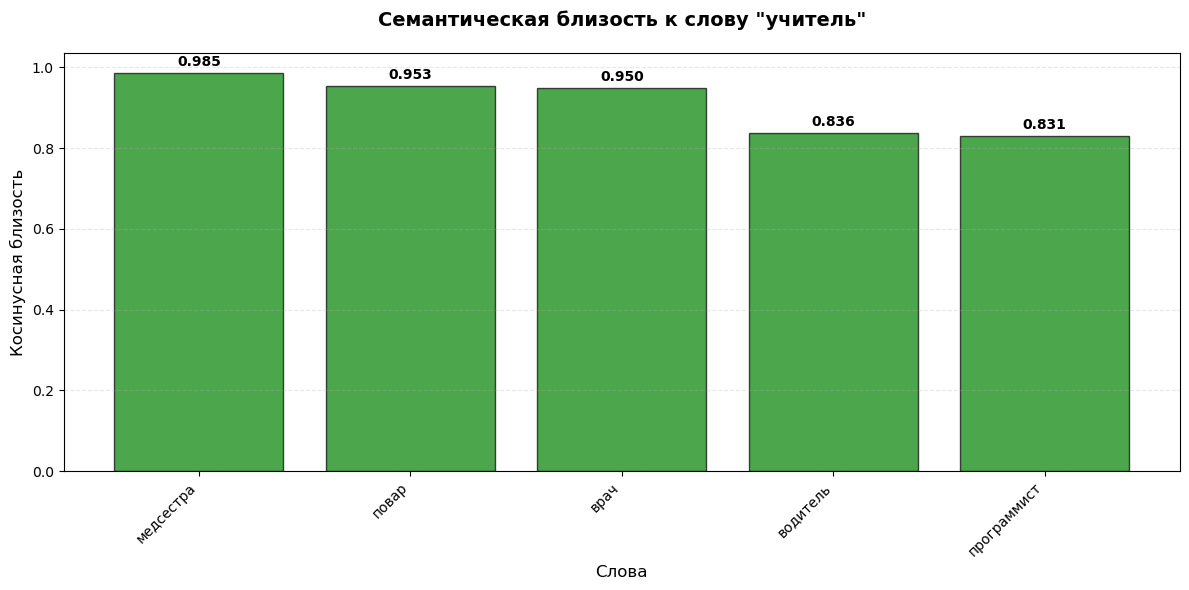

In [8]:
import matplotlib.pyplot as plt

def visualize_similarities(target_word, words_dict, top_k=5):
    similarities = {}
    target_vector = words_dict[target_word]
    
    for word, vector in words_dict.items():
        if word != target_word:
            similarity = cosine_similarity(target_vector, vector)
            similarities[word] = similarity
    
    sorted_similarities = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
    top_words = sorted_similarities[:top_k]
    
    words = [item[0] for item in top_words]
    scores = [item[1] for item in top_words]
    
    plt.figure(figsize=(12, 6))
    
    colors = []
    for score in scores:
        if score >= 0.7:
            colors.append('green')
        elif score >= 0.4:
            colors.append('orange')
        elif score >= 0:
            colors.append('lightcoral')
    
    bars = plt.bar(words, scores, color=colors, alpha=0.7, edgecolor='black')

    for bar, score in zip(bars, scores):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.title(f'Семантическая близость к слову "{target_word}"', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Слова', fontsize=12)
    plt.ylabel('Косинусная близость', fontsize=12)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

dict3 = {'врач': [0.9, 0.1, 0.8, 0.2],
               'медсестра': [0.8, 0.2, 0.7, 0.3],
               'учитель': [0.7, 0.3, 0.6, 0.4],
               'программист': [0.6, 0.4, 0.2, 0.9],
               'повар': [0.5, 0.5, 0.5, 0.5],
               'водитель': [0.4, 0.6, 0.3, 0.7]}

visualize_similarities('учитель', dict3)

In [ ]:
#3
"""Напишите программу, которая получает и выводит на экран все книги (сами выберите какие) из таблицы books тремя способами:
1.  Получить все записи с помощью fetchall().
2.  Получить записи по одной с помощью fetchone() в цикле.
3.  Получить первые 3 записи с помощью fetchmany(3).

книга в таблице это - название книги, автор, год издания
"""

In [5]:
# Enter your code here
import sqlite3

conn = sqlite3.connect('seminar10.db')
cursor = conn.cursor()

cursor.execute("SELECT title, author, year FROM books")
books = cursor.fetchall()
for book in books:
    print(f"Название: {book[0]}, Автор: {book[1]}, Год: {book[2]}")

cursor.execute("SELECT title, author, year FROM books")
while True:
    book = cursor.fetchone()
    if book is None:
        break
    print(f"Название: {book[0]}, Автор: {book[1]}, Год: {book[2]}")

cursor.execute("SELECT title, author, year FROM books")
books = cursor.fetchmany(2)
for book in books:
    print(f"Название: {book[0]}, Автор: {book[1]}, Год: {book[2]}")

conn.close()

Название: Война и мир, Автор: Лев Толстой, Год: 1869
Название: Преступление и наказание, Автор: Федор Достоевский, Год: 1866
Название: Мастер и Маргарита, Автор: Михаил Булгаков, Год: 1967
Название: Евгений Онегин, Автор: Александр Пушкин, Год: 1833
Название: Отцы и дети, Автор: Иван Тургенев, Год: 1862
Название: Война и мир, Автор: Лев Толстой, Год: 1869
Название: Преступление и наказание, Автор: Федор Достоевский, Год: 1866
Название: Мастер и Маргарита, Автор: Михаил Булгаков, Год: 1967
Название: Евгений Онегин, Автор: Александр Пушкин, Год: 1833
Название: Отцы и дети, Автор: Иван Тургенев, Год: 1862
Название: Война и мир, Автор: Лев Толстой, Год: 1869
Название: Преступление и наказание, Автор: Федор Достоевский, Год: 1866
